# 15 Activation functions in PWFFN

**[Rectified linear unit (ReLU) 2010](https://www.cs.toronto.edu/~fritz/absps/reluICML.pdf):** $\quad$ originally used,

$$\operatorname{ReLU}(a)=\max(a,0)=a\,\mathbb{I}(a>0)$$

**[Gaussian Error Linear Unit (GELU) 2016](https://arxiv.org/pdf/1606.08415):** $\quad$ used in [modelo BERT (2019)](https://arxiv.org/pdf/1810.04805)

$$
\operatorname{GELU}(a) = a * P(a)
$$

where $P(a)$ is the cumulative distribution function for a Gaussian distribution $\mathcal{N}(0,1)$. Its approximation:

$$
\operatorname{GELU}(a) = 0.5  a  (1 + \operatorname{tanh}(\sqrt{2 / \pi}  (a + 0.044715 a^3)))
$$


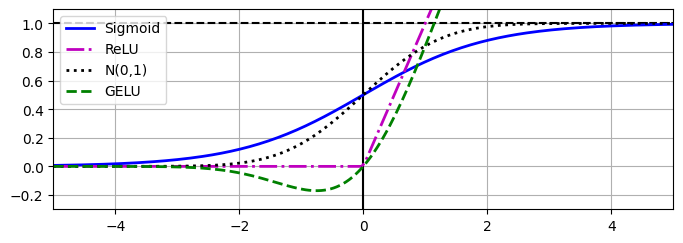

In [13]:
import torch; import matplotlib.pyplot as plt; from scipy.stats import norm; a = torch.linspace(-5, 5, 200)
plt.figure(figsize=(8,2.6)); plt.grid(True); plt.axis([-5, 5, -0.3, 1.1]); 
plt.plot([-5, 5], [-1, -1], 'k-'); plt.plot([-5, 5], [1, 1], 'k--'); plt.plot([0, 0], [-1.1, 1.1], 'k-')
sigmoid = torch.nn.Sigmoid(); plt.plot(a, sigmoid(a), "b-", linewidth=2, label="Sigmoid")
plt.plot(a, torch.maximum(a, torch.zeros_like(a)), "m-.", linewidth=2, label="ReLU");
plt.plot(a, norm.cdf(a, 0, 1), "k:", linewidth=2, label="N(0,1)");
gelu = torch.nn.GELU(); plt.plot(a, gelu(a), "g--", linewidth=2, label="GELU"); plt.legend(loc="upper left");

**[Swish Linear Unit (SiLU) 2017](https://arxiv.org/pdf/1710.05941):**

$$
\operatorname{SiLU}(a) = a \cdot \sigma(a)
$$

**[Gated Linear Unit (GLU) 2017](https://arxiv.org/pdf/1612.08083):** Generalization of SiLU

$$
\operatorname{GLU}(a,b) = a \cdot \sigma(b)
$$
where $b=aw_g+b_g$. Equivalent to $\operatorname{SiLU}(a)$ with $w_g=1$ and $b_g=0$.

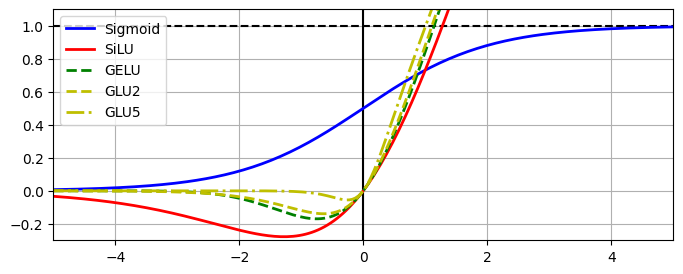

In [15]:
import torch; import matplotlib.pyplot as plt; a = torch.linspace(-5, 5, 200)
plt.figure(figsize=(8,3)); plt.grid(True); plt.axis([-5, 5, -0.3, 1.1]); 
plt.plot([-5, 5], [-1, -1], 'k-'); plt.plot([-5, 5], [1, 1], 'k--'); plt.plot([0, 0], [-1.1, 1.1], 'k-')
sigmoid = torch.nn.Sigmoid(); plt.plot(a, sigmoid(a), "b-", linewidth=2, label="Sigmoid")
silu = torch.nn.SiLU(); plt.plot(a, silu(a), "r-", linewidth=2, label="SiLU")
gelu = torch.nn.GELU(); plt.plot(a, gelu(a), "g--", linewidth=2, label="GELU");
w=2; b=0; glu = torch.nn.GLU(); plt.plot(a, glu(torch.concatenate([a,w*a+b])), "y--", linewidth=2, label="GLU2"); 
w=5; plt.plot(a, glu(torch.concatenate([a,w*a+b])), "y-.", lw=2, label="GLU5"); plt.legend(loc="upper left");

**PWFFN with GLU:**
$$\operatorname{PWFFN}(X)=\operatorname{GLU}(XW_1+\boldsymbol{1}_n\boldsymbol{b}_1^t,XW_2+\boldsymbol{1}_n\boldsymbol{b}_2^t)W_3+\boldsymbol{1}_n\boldsymbol{b}_3^t$$


**[Swish Gated Linear Unit (SwiGLU) 2020](https://arxiv.org/pdf/2002.05202):** Variant of GLU 

$$
\operatorname{SwiGLU}(a,b) = a \cdot \operatorname{SiLU}(b)
$$

where $b=aw_g+b_g$.

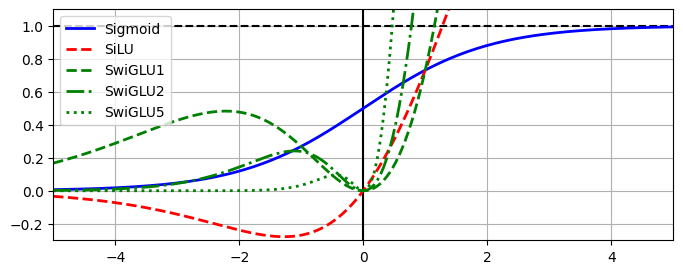

In [4]:
import torch; import matplotlib.pyplot as plt; a = torch.linspace(-5, 5, 200)
plt.figure(figsize=(8,3)); plt.grid(True); plt.axis([-5, 5, -0.3, 1.1]); 
plt.plot([-5, 5], [-1, -1], 'k-'); plt.plot([-5, 5], [1, 1], 'k--'); plt.plot([0, 0], [-1.1, 1.1], 'k-')
sigmoid = torch.nn.Sigmoid(); plt.plot(a, sigmoid(a), "b-", linewidth=2, label="Sigmoid")
silu = torch.nn.SiLU(); plt.plot(a, silu(a), "r--", linewidth=2, label="SiLU")
w=1; b=0; plt.plot(a, a*silu(w*a+b), "g--", linewidth=2, label="SwiGLU1"); 
w=2; b=0; plt.plot(a, a*silu(w*a+b), "g-.", linewidth=2, label="SwiGLU2"); 
w=5; b=0; plt.plot(a, a*silu(w*a+b), "g:", linewidth=2, label="SwiGLU5"); plt.legend(loc="upper left");

**PWFFN with SwiGLU:**
$$\operatorname{PWFFN}(X)=\operatorname{SwiGLU}(XW_1+\boldsymbol{1}_n\boldsymbol{b}_1^t,XW_2+\boldsymbol{1}_n\boldsymbol{b}_2^t)W_3+\boldsymbol{1}_n\boldsymbol{b}_3^t$$


<p style="page-break-after:always;"></p>